In [115]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.append(f"./../")
from src.misc import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Fully Disjoint Control Patterns

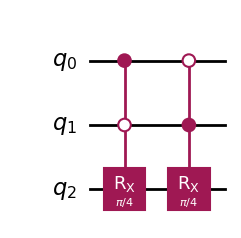

In [116]:
theta = np.pi / 4
qc = QuantumCircuit(3)
rx1 = multi_crx(theta, '10')
rx2 = multi_crx(theta, '01')
qc.append(rx1, [0,1,2])
qc.append(rx2, [0,1,2])
qc.draw('mpl')

#### Logical form

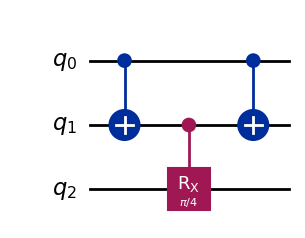

In [117]:
qc_l = QuantumCircuit(3)
qc_l.cx(0, 1)
qc_l.crx(theta, 1, 2)
qc_l.cx(0, 1)
qc_l.draw('mpl')

In [118]:
state1 = get_state(qc)
state2 = get_state(qc_l)

results = compare_quantum_states(state1, state2, tolerance=1e-10, verbose=False)

detailed_state_analysis(state1, state2)

_ = analyze_circuit_comparison(qc, qc_l)

Detailed State Analysis:
Fidelity: 1.0000000000
Number of qubits: 3
Non-zero amplitudes (tolerance=1e-10):
State Amplitude 1     Amplitude 2     Difference   Match
-----------------------------------------------------
|000⟩ 0.353553-0.000000j 0.353553+0.000000j    1.11e-16     ✓
|001⟩ 0.326641-0.135299j 0.326641-0.135299j    1.86e-16     ✓
|010⟩ 0.326641-0.135299j 0.326641-0.135299j    1.69e-16     ✓
|011⟩ 0.353553+0.000000j 0.353553+0.000000j    1.11e-16     ✓
|100⟩ 0.353553+0.000000j 0.353553+0.000000j    1.11e-16     ✓
|101⟩ 0.326641-0.135299j 0.326641-0.135299j    2.78e-16     ✓
|110⟩ 0.326641-0.135299j 0.326641-0.135299j    1.67e-16     ✓
|111⟩ 0.353553+0.000000j 0.353553+0.000000j    1.11e-16     ✓

Circuit Comparison Analysis:
Original circuit - CX: 16, U3: 17
Simplified circuit - CX: 4, U3: 3
CX gate reduction: 12 (75.00%)
U3 gate reduction: 14 (82.35%)



#### Relative Phase Form

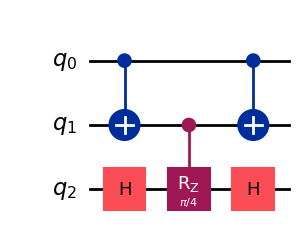

In [119]:
qc_p = QuantumCircuit(3)
qc_p.h(2)
qc_p.cx(0, 1)
qc_p.crz(theta, 1, 2)
qc_p.cx(0, 1)
qc_p.h(2)
qc_p.draw('mpl')

In [120]:
state1 = get_state(qc)
state3 = get_state(qc_p)

results = compare_quantum_states(state1, state2, tolerance=1e-10, verbose=False)

detailed_state_analysis(state1, state3)

_ = analyze_circuit_comparison(qc, qc_p)

Detailed State Analysis:
Fidelity: 1.0000000000
Number of qubits: 3
Non-zero amplitudes (tolerance=1e-10):
State Amplitude 1     Amplitude 2     Difference   Match
-----------------------------------------------------
|000⟩ 0.353553-0.000000j 0.353553+0.000000j    1.67e-16     ✓
|001⟩ 0.326641-0.135299j 0.326641-0.135299j    2.48e-16     ✓
|010⟩ 0.326641-0.135299j 0.326641-0.135299j    2.29e-16     ✓
|011⟩ 0.353553+0.000000j 0.353553+0.000000j    1.67e-16     ✓
|100⟩ 0.353553+0.000000j 0.353553+0.000000j    1.67e-16     ✓
|101⟩ 0.326641-0.135299j 0.326641-0.135299j    3.34e-16     ✓
|110⟩ 0.326641-0.135299j 0.326641-0.135299j    2.24e-16     ✓
|111⟩ 0.353553+0.000000j 0.353553+0.000000j    1.67e-16     ✓

Circuit Comparison Analysis:
Original circuit - CX: 16, U3: 17
Simplified circuit - CX: 4, U3: 3
CX gate reduction: 12 (75.00%)
U3 gate reduction: 14 (82.35%)



### Partially Overlapping Control Patterns

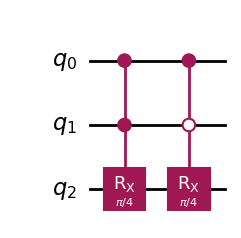

In [121]:
theta = np.pi / 4
qc = QuantumCircuit(3)
rx1 = multi_crx(theta, '11')
rx2 = multi_crx(theta, '10')
qc.append(rx1, [0,1,2])
qc.append(rx2, [0,1,2])
qc.draw('mpl')

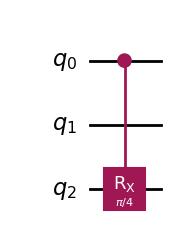

In [122]:
qc_simplified = QuantumCircuit(3)
qc_simplified.crx(theta, 0, 2)
qc_simplified.draw('mpl')

This is the optimal case where the simplification is maximal.

In [123]:
state1 = get_state(qc)
state2 = get_state(qc_simplified)

results = compare_quantum_states(state1, state2, tolerance=1e-10, verbose=False)

detailed_state_analysis(state1, state2)

_ = analyze_circuit_comparison(qc, qc_simplified)

Detailed State Analysis:
Fidelity: 1.0000000000
Number of qubits: 3
Non-zero amplitudes (tolerance=1e-10):
State Amplitude 1     Amplitude 2     Difference   Match
-----------------------------------------------------
|000⟩ 0.353553+0.000000j 0.353553+0.000000j    5.60e-17     ✓
|001⟩ 0.326641-0.135299j 0.326641-0.135299j    2.24e-16     ✓
|010⟩ 0.353553+0.000000j 0.353553+0.000000j    5.60e-17     ✓
|011⟩ 0.326641-0.135299j 0.326641-0.135299j    2.83e-16     ✓
|100⟩ 0.353553+0.000000j 0.353553+0.000000j    5.73e-17     ✓
|101⟩ 0.326641-0.135299j 0.326641-0.135299j    2.29e-16     ✓
|110⟩ 0.353553+0.000000j 0.353553+0.000000j    5.73e-17     ✓
|111⟩ 0.326641-0.135299j 0.326641-0.135299j    2.79e-16     ✓

Circuit Comparison Analysis:
Original circuit - CX: 16, U3: 15
Simplified circuit - CX: 2, U3: 3
CX gate reduction: 14 (87.50%)
U3 gate reduction: 12 (80.00%)



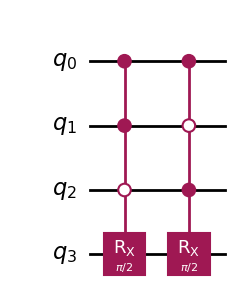

In [124]:
theta = 2*np.pi / 4
qc = QuantumCircuit(4)
rx1 = multi_crx(theta, '110')
rx2 = multi_crx(theta, '101')
qc.append(rx1, [0,1,2,3])
qc.append(rx2, [0,1,2,3])
qc.draw('mpl')

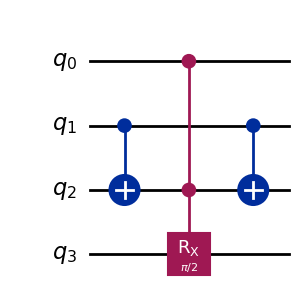

In [125]:
qc_l = QuantumCircuit(4)

rx1 = multi_crx(theta, '11')
qc_l.cx(1,2)
qc_l.append(rx1, [0, 2, 3])
qc_l.cx(1,2)

qc_l.draw('mpl')

In [126]:
state1 = get_state(qc)
state2 = get_state(qc_l)

results = compare_quantum_states(state1, state2, tolerance=1e-10, verbose=False)

detailed_state_analysis(state1, state2)

_ = analyze_circuit_comparison(qc, qc_l)

Detailed State Analysis:
Fidelity: 1.0000000000
Number of qubits: 4
Non-zero amplitudes (tolerance=1e-10):
State  Amplitude 1     Amplitude 2     Difference   Match
------------------------------------------------------
|0000⟩ 0.250000-0.000000j 0.250000+0.000000j    3.06e-16     ✓
|0001⟩ 0.250000-0.000000j 0.250000+0.000000j    2.78e-16     ✓
|0010⟩ 0.250000-0.000000j 0.250000-0.000000j    1.39e-16     ✓
|0011⟩ 0.176777-0.176777j 0.176777-0.176777j    3.10e-16     ✓
|0100⟩ 0.250000-0.000000j 0.250000-0.000000j    1.94e-16     ✓
|0101⟩ 0.176777-0.176777j 0.176777-0.176777j    3.94e-16     ✓
|0110⟩ 0.250000-0.000000j 0.250000+0.000000j    3.61e-16     ✓
|0111⟩ 0.250000+0.000000j 0.250000+0.000000j    2.78e-16     ✓
|1000⟩ 0.250000+0.000000j 0.250000+0.000000j    2.78e-16     ✓
|1001⟩ 0.250000+0.000000j 0.250000+0.000000j    3.33e-16     ✓
|1010⟩ 0.250000+0.000000j 0.250000+0.000000j    1.94e-16     ✓
|1011⟩ 0.176777-0.176777j 0.176777-0.176777j    3.94e-16     ✓
|1100⟩ 0.250000+0.000000

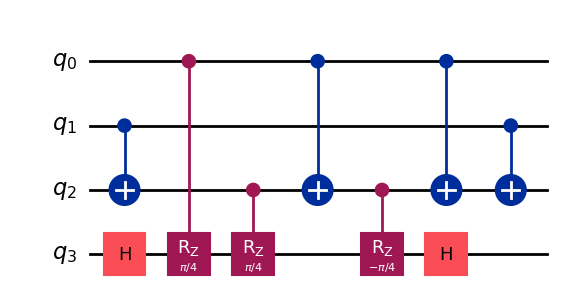

In [127]:
qc_p = QuantumCircuit(4)

qc_p.h(3)
qc_p.cx(1,2)
qc_p.crz(theta/2, 0, 3)
qc_p.crz(theta/2, 2, 3)
qc_p.cx(0,2)
qc_p.crz(-theta/2, 2, 3)
qc_p.cx(0,2)
qc_p.h(3)
qc_p.cx(1,2)

qc_p.draw('mpl')

In [128]:
state1 = get_state(qc)
state3 = get_state(qc_p)

results = compare_quantum_states(state1, state3, tolerance=1e-10, verbose=False)

detailed_state_analysis(state1, state3)

_ = analyze_circuit_comparison(qc, qc_p)

Detailed State Analysis:
Fidelity: 1.0000000000
Number of qubits: 4
Non-zero amplitudes (tolerance=1e-10):
State  Amplitude 1     Amplitude 2     Difference   Match
------------------------------------------------------
|0000⟩ 0.250000-0.000000j 0.250000+0.000000j    3.33e-16     ✓
|0001⟩ 0.250000-0.000000j 0.250000-0.000000j    2.78e-16     ✓
|0010⟩ 0.250000-0.000000j 0.250000-0.000000j    1.67e-16     ✓
|0011⟩ 0.176777-0.176777j 0.176777-0.176777j    3.35e-16     ✓
|0100⟩ 0.250000-0.000000j 0.250000-0.000000j    2.22e-16     ✓
|0101⟩ 0.176777-0.176777j 0.176777-0.176777j    4.16e-16     ✓
|0110⟩ 0.250000-0.000000j 0.250000+0.000000j    3.89e-16     ✓
|0111⟩ 0.250000+0.000000j 0.250000-0.000000j    2.78e-16     ✓
|1000⟩ 0.250000+0.000000j 0.250000+0.000000j    2.78e-16     ✓
|1001⟩ 0.250000+0.000000j 0.250000-0.000000j    3.34e-16     ✓
|1010⟩ 0.250000+0.000000j 0.250000-0.000000j    1.67e-16     ✓
|1011⟩ 0.176777-0.176777j 0.176777-0.176777j    4.13e-16     ✓
|1100⟩ 0.250000+0.000000

### Subset Control Patterns

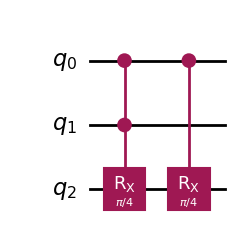

In [129]:
theta = np.pi / 4
qc = QuantumCircuit(3)
rx1 = multi_crx(theta, '11')
qc.append(rx1, [0,1,2])
qc.crx(theta, 0, 2)
qc.draw('mpl')

The logical form and original form are same for this one

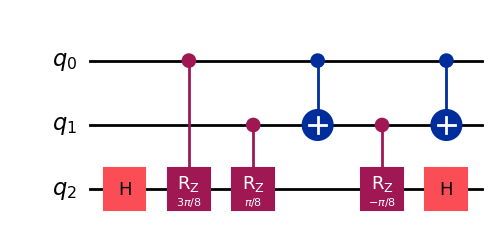

In [130]:
qc_simplified = QuantumCircuit(3)
qc_simplified.h(2)
qc_simplified.crz(theta + theta/2, 0, 2)
# qc_simplified.crz(theta/2, 0, 2)
qc_simplified.crz(theta/2, 1, 2)
qc_simplified.cx(0, 1)
qc_simplified.crz(-theta/2, 1, 2)
qc_simplified.cx(0, 1)
qc_simplified.h(2)
qc_simplified.draw('mpl')

In [131]:
state1 = get_state(qc)
state2 = get_state(qc_simplified)

results = compare_quantum_states(state1, state2, tolerance=1e-10, verbose=False)

detailed_state_analysis(state1, state2)

_ = analyze_circuit_comparison(qc, qc_simplified)

Detailed State Analysis:
Fidelity: 1.0000000000
Number of qubits: 3
Non-zero amplitudes (tolerance=1e-10):
State Amplitude 1     Amplitude 2     Difference   Match
-----------------------------------------------------
|000⟩ 0.353553-0.000000j 0.353553+0.000000j    5.55e-17     ✓
|001⟩ 0.326641-0.135299j 0.326641-0.135299j    1.24e-16     ✓
|010⟩ 0.353553+0.000000j 0.353553+0.000000j    1.11e-16     ✓
|011⟩ 0.250000-0.250000j 0.250000-0.250000j    1.78e-16     ✓
|100⟩ 0.353553+0.000000j 0.353553+0.000000j    5.55e-17     ✓
|101⟩ 0.326641-0.135299j 0.326641-0.135299j    1.24e-16     ✓
|110⟩ 0.353553+0.000000j 0.353553+0.000000j    1.12e-16     ✓
|111⟩ 0.250000-0.250000j 0.250000-0.250000j    1.78e-16     ✓

Circuit Comparison Analysis:
Original circuit - CX: 8, U3: 10
Simplified circuit - CX: 8, U3: 7
CX gate reduction: 0 (0.00%)
U3 gate reduction: 3 (30.00%)



no simplification happens

### Identical Control Patterns

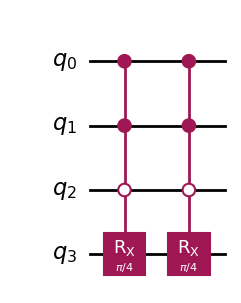

In [132]:
theta = np.pi / 4
qc = QuantumCircuit(4)
rx1 = multi_crx(theta, '110')
rx2 = multi_crx(theta, '110')
qc.append(rx1, [0,1,2,3])
qc.append(rx2, [0,1,2,3])
qc.draw('mpl')

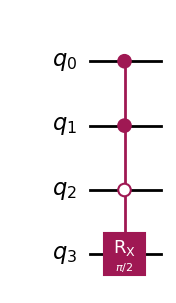

In [133]:
qc_l = QuantumCircuit(4)
rx1 = multi_crx(2*theta, '110')
qc_l.append(rx1, [0,1,2,3])
qc_l.draw('mpl')

In [134]:
state1 = get_state(qc)
state2 = get_state(qc_l)

results = compare_quantum_states(state1, state2, tolerance=1e-10, verbose=False)

detailed_state_analysis(state1, state2)

_ = analyze_circuit_comparison(qc, qc_l)

Detailed State Analysis:
Fidelity: 1.0000000000
Number of qubits: 4
Non-zero amplitudes (tolerance=1e-10):
State  Amplitude 1     Amplitude 2     Difference   Match
------------------------------------------------------
|0000⟩ 0.250000-0.000000j 0.250000+0.000000j    1.39e-16     ✓
|0001⟩ 0.250000-0.000000j 0.250000+0.000000j    8.39e-17     ✓
|0010⟩ 0.250000+0.000000j 0.250000-0.000000j    8.50e-17     ✓
|0011⟩ 0.176777-0.176777j 0.176777-0.176777j    1.00e-16     ✓
|0100⟩ 0.250000+0.000000j 0.250000+0.000000j    8.33e-17     ✓
|0101⟩ 0.250000+0.000000j 0.250000-0.000000j    1.94e-16     ✓
|0110⟩ 0.250000+0.000000j 0.250000-0.000000j    1.95e-16     ✓
|0111⟩ 0.250000+0.000000j 0.250000-0.000000j    1.39e-16     ✓
|1000⟩ 0.250000+0.000000j 0.250000+0.000000j    3.80e-18     ✓
|1001⟩ 0.250000+0.000000j 0.250000+0.000000j    5.55e-17     ✓
|1010⟩ 0.250000-0.000000j 0.250000+0.000000j    1.25e-17     ✓
|1011⟩ 0.176777-0.176777j 0.176777-0.176777j    2.78e-17     ✓
|1100⟩ 0.250000-0.000000

no advantage by using relative phase approach on a single gate as qiskit transpilled circuit is the most optimal in this case